# Day 2 — Conv2d and pooling

Use PyTorch `Conv2d` and `MaxPool2d` to connect manual filters to CNN layers.

Official docs:

- [`torch.nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [`torch.nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)


## Shape convention: `[batch, channels, height, width]`

PyTorch convolution layers expect image-like tensors in this order:

```text
[batch, channels, height, width]
```

For example, a tensor with shape `torch.Size([1, 1, 8, 8])` means:

- `batch = 1`: one image is being processed.
- `channels = 1`: the image has one value grid, so it is grayscale.
- `height = 8`: the image is 8 pixels tall.
- `width = 8`: the image is 8 pixels wide.

This shape habit matters because `Conv2d` needs its `in_channels` value to match the input image's channel count.


image_batch shape: torch.Size([1, 1, 256, 256])


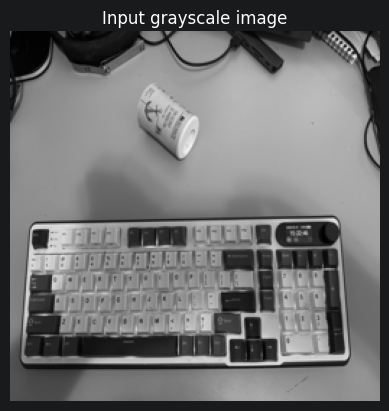

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn

image_path = Path("../data/my_sample_image.jpg")
output_dir = Path("../outputs/day02_conv2d_pooling")
output_dir.mkdir(parents=True, exist_ok=True)

gray_image = Image.open(image_path).convert("L").resize((256, 256))
gray_array = np.array(gray_image, dtype=np.float32) / 255.0

# PyTorch Conv2d expects BCHW: [batch, channels, height, width].
image_batch = torch.from_numpy(gray_array).unsqueeze(0).unsqueeze(0)

print("image_batch shape:", image_batch.shape)

plt.imshow(image_batch[0, 0], cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Input grayscale image")
plt.show()


## Conv2d: producing a feature map

A `Conv2d` layer slides a small grid of numbers, called a **kernel** or **filter**, across the image. At each location, the filter produces one number that says how strongly that local patch matched the filter pattern. The full grid of those numbers is the **feature map**.

For one grayscale input and one fixed edge-detection filter, the layer setup is conceptually:

```python
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)
```

The convolution weight tensor uses this shape:

```text
[out_channels, in_channels, kernel_height, kernel_width]
```

So `conv.weight[0, 0]` means: first output feature map, first input channel, and the 3×3 filter values for that channel.

### Why `[0, 0]`?

A `Conv2d` weight tensor is indexed in this order:

```text
[which output feature map, which input channel, kernel row, kernel column]
```

In this notebook, the input image shape is `torch.Size([1, 1, 256, 256])`. The second `1` means the image has one grayscale channel, so the layer uses `in_channels=1`.

The layer also uses `out_channels=1` because we only want to create one fixed edge-detection feature map for now. With one output feature map and one input channel, the only available kernel slot is `conv.weight[0, 0]`.

If the input image were RGB, the input would have 3 channels, so the layer would need `in_channels=3`. If the layer had `out_channels=4`, it would learn or store 4 different filters and produce 4 output feature maps.


In [4]:
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=1,
    bias=False,
)

# This filter responds strongly when brightness changes left-to-right.
edge_kernel = torch.tensor(
    [
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0],
    ]
)

with torch.no_grad():
    conv.weight[0, 0] = edge_kernel

. feature_map = conv(image_batch)

print("conv.weight shape:", conv.weight.shape)
print("feature_map shape:", feature_map.shape)


conv.weight shape: torch.Size([1, 1, 3, 3])
feature_map shape: torch.Size([1, 1, 256, 256])


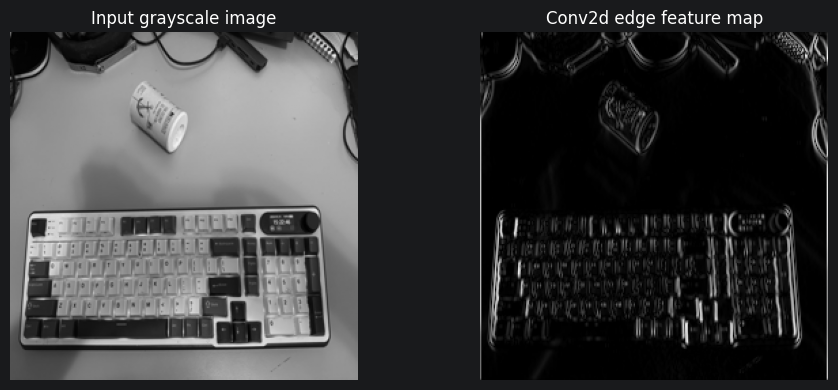

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image_batch[0, 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input grayscale image")
axes[0].axis("off")

axes[1].imshow(feature_map[0, 0].detach().abs(), cmap="gray")
axes[1].set_title("Conv2d edge feature map")
axes[1].axis("off")

plt.tight_layout()
fig.savefig(output_dir / "conv2d_feature_map_grid.png", dpi=150, bbox_inches="tight")
plt.show()


## Pooling on a 6×6 toy image

Before pooling the real `Conv2d` feature map, use a tiny 6×6 grid so the shape change is easy to see.

`MaxPool2d(kernel_size=2, stride=2)` looks at each non-overlapping 2×2 patch and keeps the largest value from that patch. Starting from one 6×6 image, that creates a 3×3 output because each pair of rows and each pair of columns becomes one pooled value.

Shape reading:

```text
[1, 1, 6, 6] -> [1, 1, 3, 3]
```

The first `1` still means one image, and the second `1` still means one channel. Pooling changes only height and width.

### Why pool?

Pooling is useful after a convolution has already produced a feature map. The convolution answers, “where did this filter respond strongly?” Pooling then answers, “was there a strong response somewhere in this small area?”

This gives the next layer fewer numbers to process, because the height and width get smaller. For example, one `256×256` feature map has 65,536 values, but after `2×2` max pooling it has `128×128 = 16,384` values.

Pooling also keeps strong local signals while giving up some exact pixel position. If an edge response shifts by one pixel, the pooled map may still keep a strong value in the same nearby region. This is why the pooled image can look coarser but still similar to the original feature map.

That coarser map can help later layers combine small signals into larger patterns. After pooling, each cell summarizes a larger area of the previous feature map, so a later convolution sees a bigger part of the original image at once.

For this notebook, the important distinction is: `Conv2d` creates the edge-response feature map; `MaxPool2d` shrinks that existing feature map while keeping strong nearby responses.


toy image shape: torch.Size([1, 1, 6, 6])
tensor([[ 1.,  2.,  3.,  4.,  5.,  6.],
        [ 7.,  8.,  9., 10., 11., 12.],
        [13., 14., 15., 16., 17., 18.],
        [19., 20., 21., 22., 23., 24.],
        [25., 26., 27., 28., 29., 30.],
        [31., 32., 33., 34., 35., 36.]])
pooled toy shape: torch.Size([1, 1, 3, 3])
tensor([[ 8., 10., 12.],
        [20., 22., 24.],
        [32., 34., 36.]])


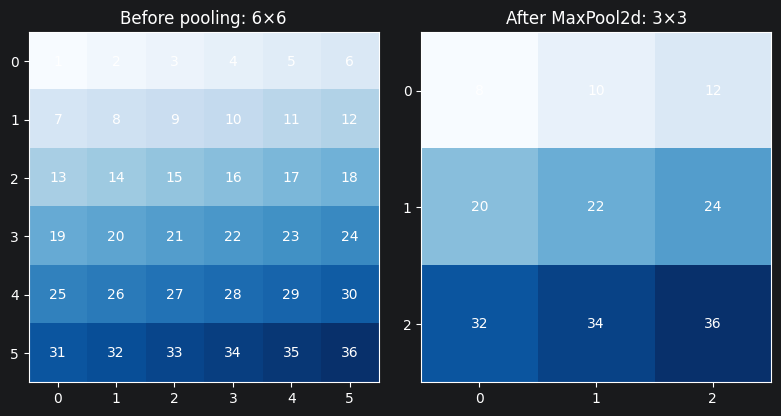

In [9]:
toy_image = torch.arange(1, 37, dtype=torch.float32).reshape(1, 1, 6, 6)
toy_pool = nn.MaxPool2d(kernel_size=2, stride=2)
toy_pooled = toy_pool(toy_image)

print("toy image shape:", toy_image.shape)
print(toy_image[0, 0])
print("pooled toy shape:", toy_pooled.shape)
print(toy_pooled[0, 0])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(toy_image[0, 0], cmap="Blues")
axes[0].set_title("Before pooling: 6×6")
axes[0].set_xticks(range(6))
axes[0].set_yticks(range(6))

for row in range(6):
    for col in range(6):
        axes[0].text(col, row, int(toy_image[0, 0, row, col].item()), ha="center", va="center")

axes[1].imshow(toy_pooled[0, 0], cmap="Blues")
axes[1].set_title("After MaxPool2d: 3×3")
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))

for row in range(3):
    for col in range(3):
        axes[1].text(col, row, int(toy_pooled[0, 0, row, col].item()), ha="center", va="center")

plt.tight_layout()
plt.show()


### Real pooling cell

In [8]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)

pooled_feature_map = pool(feature_map)

print("before pooling:", feature_map.shape)
print("after pooling:", pooled_feature_map.shape)

before pooling: torch.Size([1, 1, 256, 256])
after pooling: torch.Size([1, 1, 128, 128])


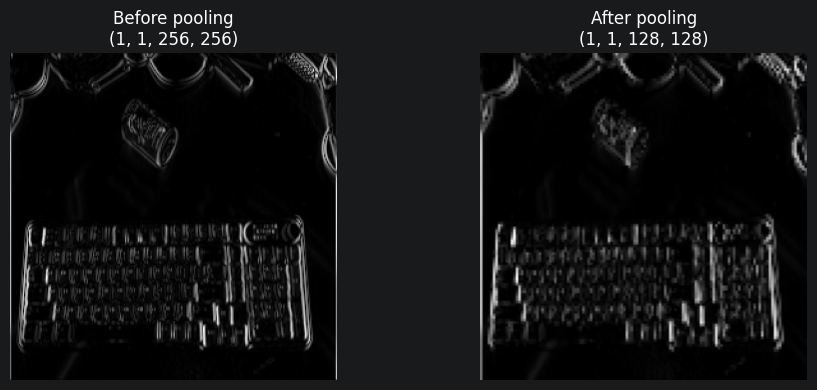

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(feature_map[0, 0].detach().abs(), cmap="gray")
axes[0].set_title(f"Before pooling\n{tuple(feature_map.shape)}")
axes[0].axis("off")

axes[1].imshow(pooled_feature_map[0, 0].detach().abs(), cmap="gray")
axes[1].set_title(f"After pooling\n{tuple(pooled_feature_map.shape)}")
axes[1].axis("off")

plt.tight_layout()

fig.savefig(output_dir / "pooling_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

## Reflection

Write this in your own words after inspecting the before/after pooling plot. Use the printed shapes as evidence.

- The `Conv2d` layer produced a feature map with shape `torch.Size([1, 1, 256, 256])`. In `[batch, channels, height, width]`, this means ...
- `MaxPool2d` changed the shape to `torch.Size([1, 1, 128, 128])`. This means ...
- Visually, the pooled map looked ... compared with the original feature map.
- The key distinction is: `Conv2d` ..., while `MaxPool2d` ...
